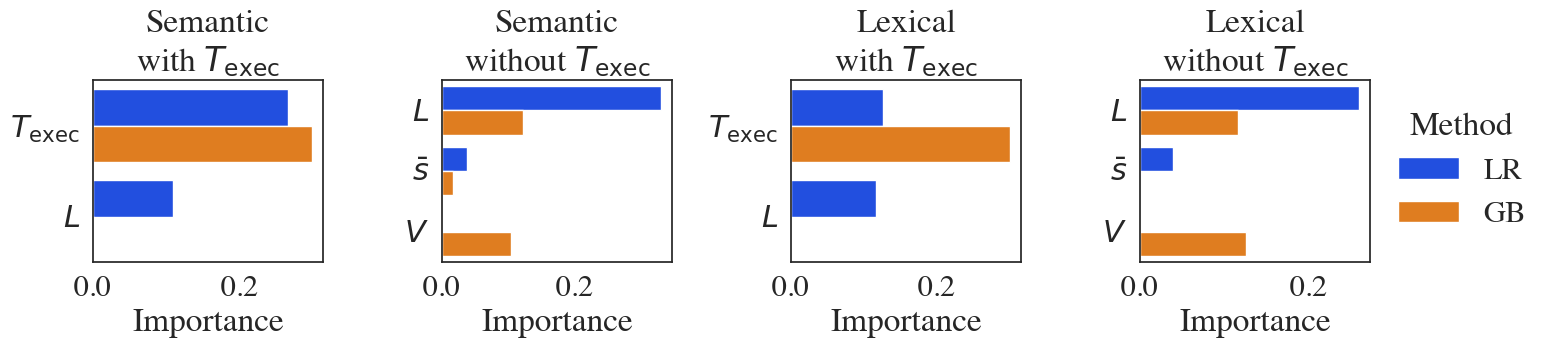

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


DATA = [
    # Semantic - with T_exec
    {"Type": "Semantic", "Method": "LR", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$T_{\operatorname{exec}}$", "Importance": 0.267102, "Std": 0.007894},
    {"Type": "Semantic", "Method": "LR", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.109332, "Std": 0.003354},
    {"Type": "Semantic", "Method": "GB", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$T_{\operatorname{exec}}$", "Importance": 0.299541, "Std": 0.007255},
    {"Type": "Semantic", "Method": "GB", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.000953, "Std": 0.000476},

    # Semantic - without T_exec
    {"Type": "Semantic", "Method": "LR", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.330904, "Std": 0.005909},
    {"Type": "Semantic", "Method": "LR", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$\bar{s}$", "Importance": 0.037226, "Std": 0.003784},
    {"Type": "Semantic", "Method": "GB", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.121540, "Std": 0.003162},
    {"Type": "Semantic", "Method": "GB", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$V$", "Importance": 0.103630, "Std": 0.002973},
    {"Type": "Semantic", "Method": "GB", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$\bar{s}$", "Importance": 0.016989, "Std": 0.001415},

    # Lexical - with T_exec
    {"Type": "Lexical", "Method": "LR", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$T_{\operatorname{exec}}$", "Importance": 0.125772, "Std": 0.003893},
    {"Type": "Lexical", "Method": "LR", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.116428, "Std": 0.003157},
    {"Type": "Lexical", "Method": "GB", "Condition": r"with $T_{\operatorname{exec}}$", "Feature": r"$T_{\operatorname{exec}}$", "Importance": 0.299856, "Std": 0.007234},

    # Lexical - without T_exec
    {"Type": "Lexical", "Method": "LR", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.260240, "Std": 0.006875},
    {"Type": "Lexical", "Method": "LR", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$\bar{s}$", "Importance": 0.039271, "Std": 0.002256},
    {"Type": "Lexical", "Method": "GB", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$V$", "Importance": 0.125334, "Std": 0.002616},
    {"Type": "Lexical", "Method": "GB", "Condition": r"without $T_{\operatorname{exec}}$", "Feature": r"$L$", "Importance": 0.115819, "Std": 0.002608},
]

df = pd.DataFrame(DATA)

# Setup the figure and shared X-axis for easier comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sns.set_theme(style="white", palette="bright", font='times', font_scale=2)

# Define the sequence of subplots as requested
scenarios = [
    ("Semantic", r"with $T_{\operatorname{exec}}$"),
    ("Semantic", r"without $T_{\operatorname{exec}}$"),
    ("Lexical", r"with $T_{\operatorname{exec}}$"),
    ("Lexical", r"without $T_{\operatorname{exec}}$")
]

for i, (dtype, cond) in enumerate(scenarios):
    # Filter the data for the specific subplot
    subset = df[(df["Type"] == dtype) & (df["Condition"] == cond)]
    
    # Create the horizontal bar plot
    sns.barplot(
        data=subset, 
        y="Feature", 
        x="Importance", 
        hue="Method", 
        ax=axes[i],
        orient='h'
    )
    
    # Formatting
    axes[i].set_title(f"{dtype}\n{cond}")
    axes[i].set_xlabel("Importance") # Only label first X-axis
    axes[i].set_ylabel("") 
    
    # Only keep the legend for the last plot to save space
    if i != 3:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Method", loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

root_dir = Path("../")

plt.tight_layout()
plt.savefig(root_dir / "paper" / "exp1.pdf", bbox_inches="tight")
plt.show()